In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic=pd.read_csv("Titanic-Dataset.csv")

In [3]:
features=["Pclass","Sex","Fare","Embarked","Age"]
target=["Survived"]

In [4]:
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
titanic[["Age"]]=imp_median.fit_transform(titanic[["Age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["Embarked"]]=imp_freq.fit_transform(titanic[["Embarked"]])

In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

titanic["Sex"]=le.fit_transform(titanic["Sex"])
titanic["Embarked"]=le.fit_transform(titanic["Embarked"])

In [6]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


In [23]:
x=titanic[features]
y=titanic["Survived"]

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.776536312849162


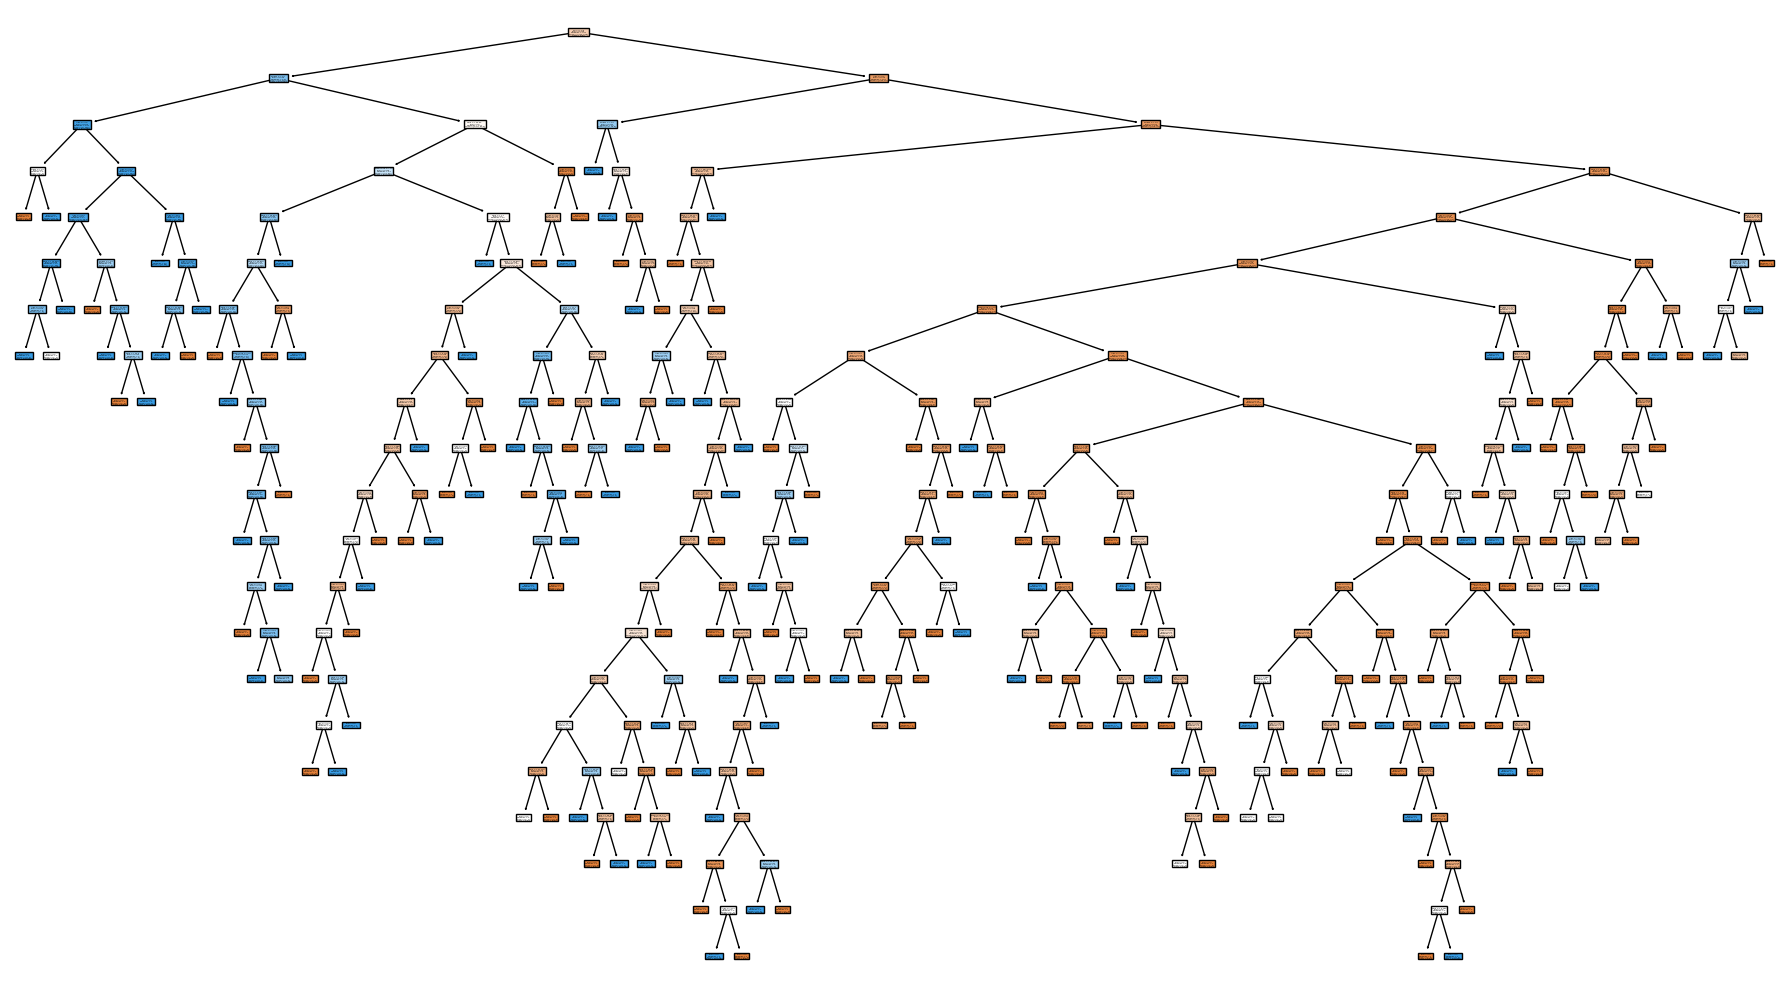

In [27]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [28]:
max_depths=[2,3,4,5,6,7,8,9,10]
for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f"for depth={depth},accuracy={acc}")

for depth=2,accuracy=0.7653631284916201
for depth=3,accuracy=0.7988826815642458
for depth=4,accuracy=0.7988826815642458
for depth=5,accuracy=0.7988826815642458
for depth=6,accuracy=0.7988826815642458
for depth=7,accuracy=0.7932960893854749
for depth=8,accuracy=0.7932960893854749
for depth=9,accuracy=0.7932960893854749
for depth=10,accuracy=0.7932960893854749


In [29]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
path=full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [31]:
trees=[]
for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(x_train,y_train)
    trees.append((model,alpha))
best_acc=0
best_alpha=0
for model,alpha in trees:
    curr_acc=model.score(x_test,y_test)
    if curr_acc>best_acc:
        best_acc=curr_acc
        best_alpha=alpha

best_acc

0.8379888268156425

In [32]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


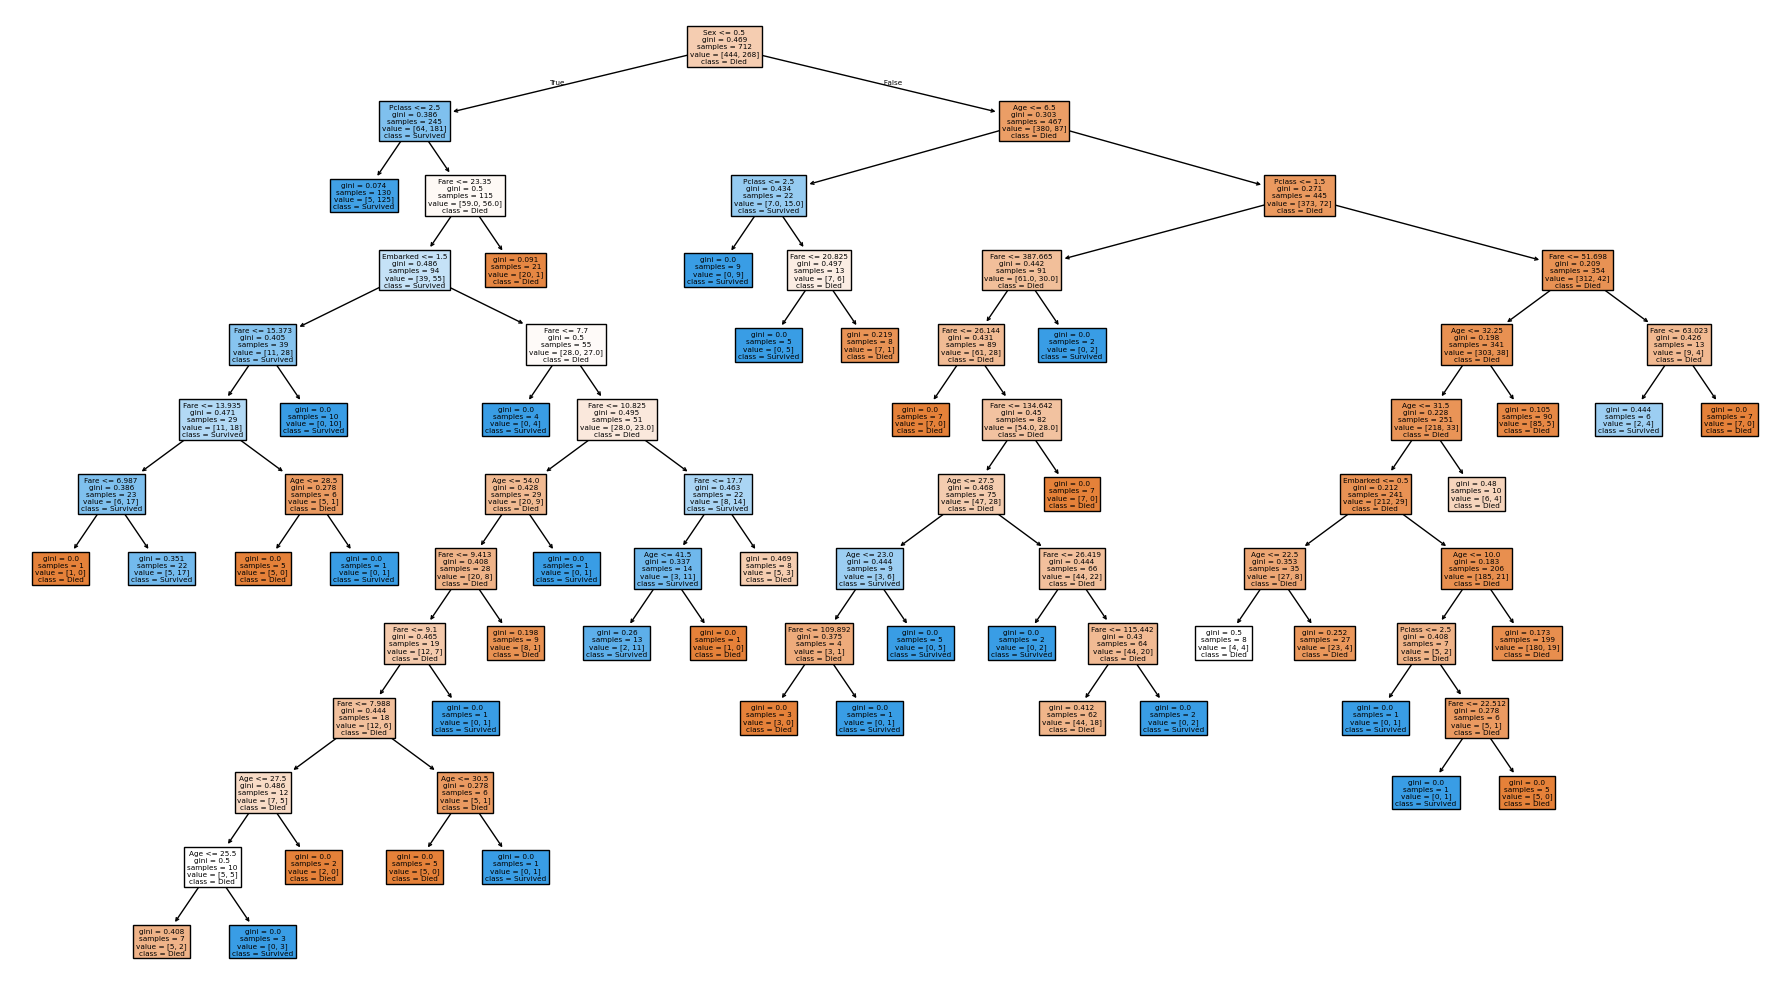

In [33]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=301,
    oob_score=True,
    max_depth=6
)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

print("OOB Score:",rf.oob_score_)


OOB Score: 0.8342696629213483


In [52]:
from sklearn.ensemble import BaggingClassifier
base_model=DecisionTreeClassifier()
bagging=BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(x_train,y_train)
y_pred=bagging.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.7877094972067039


In [60]:
from sklearn.linear_model import LogisticRegression

base_model=LogisticRegression(max_iter=1000)
bagging=BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(x_train,y_train)
y_pred=bagging.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))



accuracy: 0.7988826815642458
